In [7]:
!ls /kaggle/input/datasets/lovego1012/

project-files


In [8]:
!find /kaggle/input -name "*.py"

/kaggle/input/datasets/lovego1012/project-files/infer.py
/kaggle/input/datasets/lovego1012/project-files/train.py
/kaggle/input/datasets/lovego1012/project-files/crnn_train.py
/kaggle/input/datasets/lovego1012/project-files/model.py
/kaggle/input/datasets/lovego1012/project-files/crnn_model.py


In [9]:
!cp /kaggle/input/datasets/lovego1012/project-files/*.py /kaggle/working/
%cd /kaggle/working
!ls

/kaggle/working
crnn_model.py  crnn_train.py  infer.py	model.py  train.py


In [11]:
!python train.py --dataset mnist --epochs 10

Using device: cuda
100%|██████████████████████████████████████| 9.91M/9.91M [00:00<00:00, 31.1MB/s]
100%|███████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 988kB/s]
100%|██████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 6.28MB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 15.7MB/s]
Dataset: mnist | Classes: 10 | Train batches: 469 | Test batches: 79
Model parameters: 871,018
Epoch  1/10 | train_loss=0.3441 train_acc=0.8903 | val_loss=0.0469 val_acc=0.9839 | 16.2s
  -> saved new best checkpoint (0.9839) to ./checkpoints/mnist_best.pt
Epoch  2/10 | train_loss=0.1291 train_acc=0.9615 | val_loss=0.0316 val_acc=0.9894 | 14.6s
  -> saved new best checkpoint (0.9894) to ./checkpoints/mnist_best.pt
Epoch  3/10 | train_loss=0.1059 train_acc=0.9687 | val_loss=0.0278 val_acc=0.9907 | 14.6s
  -> saved new best checkpoint (0.9907) to ./checkpoints/mnist_best.pt
Epoch  4/10 | train_loss=0.0944 train_acc=0.9722 | val_loss=0.0240 val_acc=0.99

In [12]:
!python train.py --dataset emnist --emnist-split balanced --epochs 15

Using device: cuda
100%|█████████████████████████████████████████| 562M/562M [00:02<00:00, 247MB/s]
Dataset: emnist | Classes: 47 | Train batches: 882 | Test batches: 147
Model parameters: 880,527
Epoch  1/15 | train_loss=1.3535 train_acc=0.5881 | val_loss=0.4854 val_acc=0.8345 | 29.4s
  -> saved new best checkpoint (0.8345) to ./checkpoints/balanced_best.pt
Epoch  2/15 | train_loss=0.8290 train_acc=0.7307 | val_loss=0.4314 val_acc=0.8432 | 28.9s
  -> saved new best checkpoint (0.8432) to ./checkpoints/balanced_best.pt
Epoch  3/15 | train_loss=0.7473 train_acc=0.7531 | val_loss=0.3978 val_acc=0.8581 | 29.2s
  -> saved new best checkpoint (0.8581) to ./checkpoints/balanced_best.pt
Epoch  4/15 | train_loss=0.7031 train_acc=0.7661 | val_loss=0.4035 val_acc=0.8629 | 28.3s
  -> saved new best checkpoint (0.8629) to ./checkpoints/balanced_best.pt
Epoch  5/15 | train_loss=0.6709 train_acc=0.7774 | val_loss=0.3852 val_acc=0.8655 | 28.5s
  -> saved new best checkpoint (0.8655) to ./checkpoints/

In [13]:
!find /kaggle/input -iname "image1*"

/kaggle/input/datasets/lovego1012/image1


In [14]:
!ls -la /kaggle/input/datasets/lovego1012/image1

total 60
drwxr-xr-x 2 nobody nogroup     0 Sep  6 00:22 .
drwxr-xr-x 4 root   root     4096 Sep  6 00:22 ..
-rw-r--r-- 1 nobody nogroup 56695 Sep  6 00:22 letter1.jpeg


In [15]:
!python infer.py --checkpoint checkpoints/balanced_best.pt --image /kaggle/input/datasets/lovego1012/image1/letter1.jpeg --dataset emnist


Predicted character: 'R'  (confidence: 32.88%)


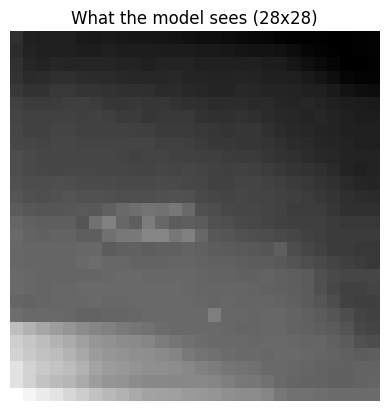

In [16]:
import matplotlib.pyplot as plt
from infer import load_and_preprocess

x = load_and_preprocess("/kaggle/input/datasets/lovego1012/image1/letter1.jpeg")
plt.imshow(x.squeeze().numpy(), cmap="gray")
plt.title("What the model sees (28x28)")
plt.axis("off")
plt.show()


In [17]:
import glob
files = sorted(glob.glob("/kaggle/input/datasets/lovego1012/image2/*"))
print(files)

['/kaggle/input/datasets/lovego1012/image2/letter10.jpeg', '/kaggle/input/datasets/lovego1012/image2/letter11.jpeg', '/kaggle/input/datasets/lovego1012/image2/letter12.jpeg', '/kaggle/input/datasets/lovego1012/image2/letter13.jpeg', '/kaggle/input/datasets/lovego1012/image2/letter14.jpeg', '/kaggle/input/datasets/lovego1012/image2/letter15.jpeg', '/kaggle/input/datasets/lovego1012/image2/letter16.jpeg', '/kaggle/input/datasets/lovego1012/image2/letter17.jpeg', '/kaggle/input/datasets/lovego1012/image2/letter18.jpeg', '/kaggle/input/datasets/lovego1012/image2/letter19.jpeg', '/kaggle/input/datasets/lovego1012/image2/letter2.jpeg', '/kaggle/input/datasets/lovego1012/image2/letter20.jpeg', '/kaggle/input/datasets/lovego1012/image2/letter21.jpeg', '/kaggle/input/datasets/lovego1012/image2/letter22.jpeg', '/kaggle/input/datasets/lovego1012/image2/letter23.jpeg', '/kaggle/input/datasets/lovego1012/image2/letter24.jpeg', '/kaggle/input/datasets/lovego1012/image2/letter25.jpeg', '/kaggle/input

In [18]:
import re
import glob
import torch
from infer import load_and_preprocess, EMNIST_BALANCED_LABELS
from model import CharCNN

# Load model once
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load("checkpoints/balanced_best.pt", map_location=device)
model = CharCNN(num_classes=ckpt["num_classes"]).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# Get files sorted numerically (letter2, letter3, ..., letter26 — not alphabetically)
files = glob.glob("/kaggle/input/datasets/lovego1012/image2/*.jpeg")
files.sort(key=lambda f: int(re.search(r'letter(\d+)', f).group(1)))

print(f"{'File':<15} {'Predicted':<12} {'Confidence':<10}")
print("-" * 40)

for f in files:
    x = load_and_preprocess(f).to(device)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        conf, pred_idx = probs.max(dim=1)
    label = EMNIST_BALANCED_LABELS[pred_idx.item()]
    fname = f.split("/")[-1]
    print(f"{fname:<15} {label:<12} {conf.item():.2%}")

File            Predicted    Confidence
----------------------------------------
letter2.jpeg    q            20.61%
letter3.jpeg    e            46.34%
letter4.jpeg    e            59.20%
letter5.jpeg    W            45.75%
letter6.jpeg    Q            40.38%
letter7.jpeg    e            54.21%
letter8.jpeg    e            53.00%
letter9.jpeg    Q            42.69%
letter10.jpeg   Q            22.49%
letter11.jpeg   e            53.05%
letter12.jpeg   e            59.43%
letter13.jpeg   Q            45.26%
letter14.jpeg   Q            39.70%
letter15.jpeg   Q            28.85%
letter16.jpeg   Q            44.47%
letter17.jpeg   Q            64.29%
letter18.jpeg   e            51.34%
letter19.jpeg   W            30.54%
letter20.jpeg   Q            23.48%
letter21.jpeg   Q            45.68%
letter22.jpeg   Q            39.40%
letter23.jpeg   Q            34.72%
letter24.jpeg   Q            23.78%
letter25.jpeg   Q            50.52%
letter26.jpeg   Q            44.46%


In [19]:
import matplotlib.pyplot as plt
from infer import load_and_preprocess
import glob, re

files = glob.glob("/kaggle/input/datasets/lovego1012/image2/*.jpeg")
files.sort(key=lambda f: int(re.search(r'letter(\d+)', f).group(1)))[:25]

fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for ax, f in zip(axes.flat, files[:15]):
    x = load_and_preprocess(f)
    ax.imshow(x.squeeze().numpy(), cmap="gray")
    ax.set_title(f.split("/")[-1], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig('/kaggle/working/grid.png')
plt.show()

TypeError: 'NoneType' object is not subscriptable

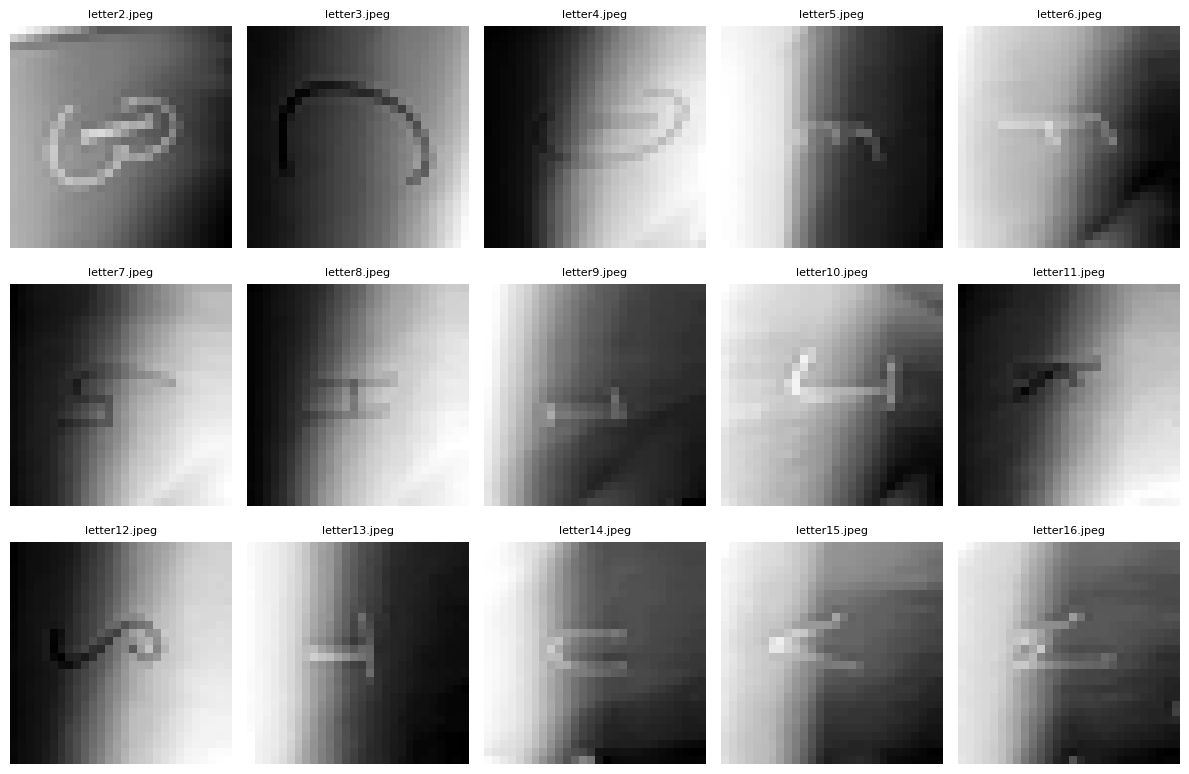

In [20]:
import matplotlib.pyplot as plt
from infer import load_and_preprocess
import glob, re

files = glob.glob("/kaggle/input/datasets/lovego1012/image2/*.jpeg")
files.sort(key=lambda f: int(re.search(r'letter(\d+)', f).group(1)))
files = files[:15]

fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for ax, f in zip(axes.flat, files):
    x = load_and_preprocess(f)
    ax.imshow(x.squeeze().numpy(), cmap="gray")
    ax.set_title(f.split("/")[-1], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig('/kaggle/working/grid.png')
plt.show()

In [21]:
/kaggle/working/grid.png

NameError: name 'kaggle' is not defined

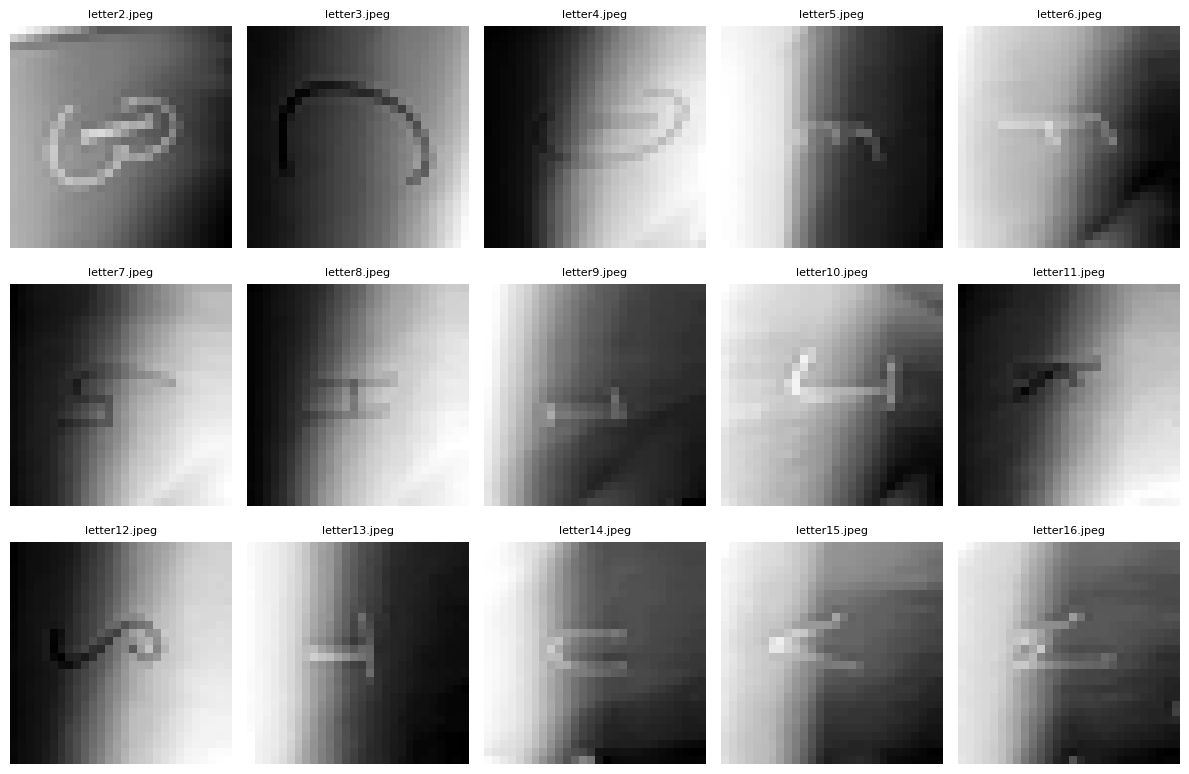

In [22]:
import matplotlib.pyplot as plt
from infer import load_and_preprocess
import glob, re

files = glob.glob("/kaggle/input/datasets/lovego1012/image2/*.jpeg")
files.sort(key=lambda f: int(re.search(r'letter(\d+)', f).group(1)))
files = files[:15]

fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for ax, f in zip(axes.flat, files):
    x = load_and_preprocess(f)
    ax.imshow(x.squeeze().numpy(), cmap="gray")
    ax.set_title(f.split("/")[-1], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig('/kaggle/working/grid.png')
plt.show()

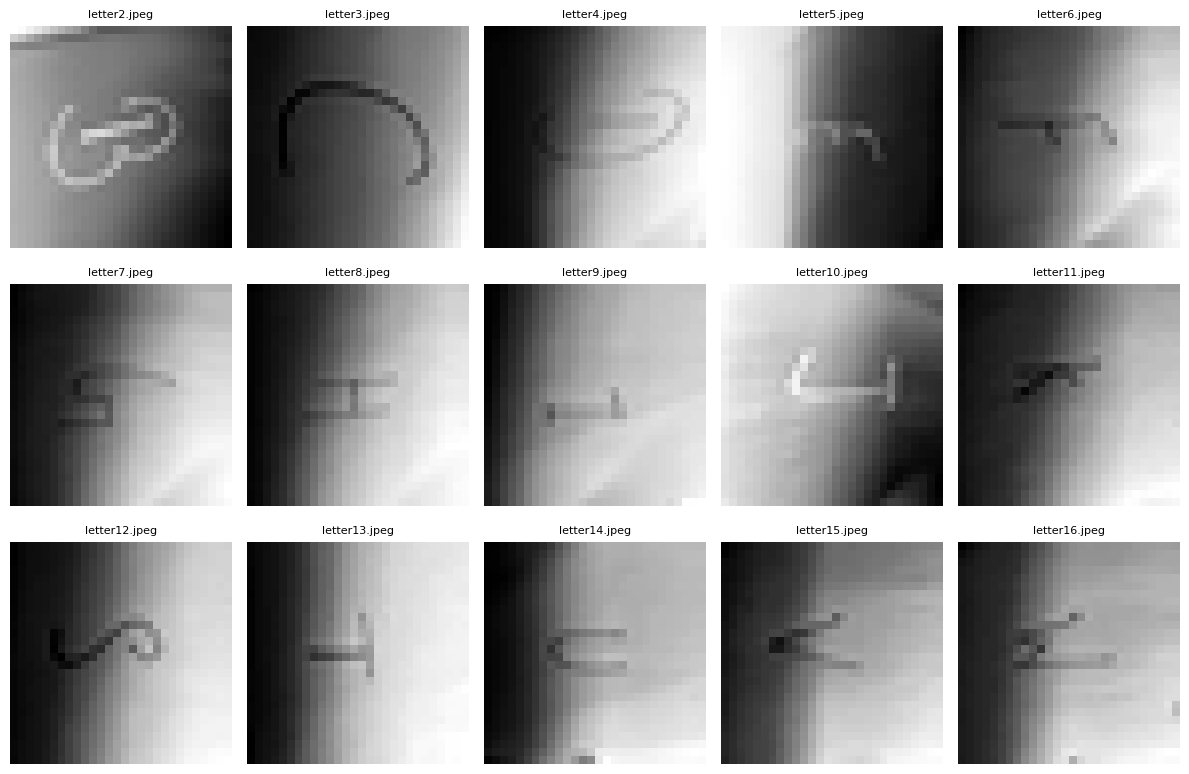

In [23]:
import torch
from PIL import Image, ImageOps
from torchvision import transforms
import glob, re

def fixed_preprocess(image_path, dataset="emnist"):
    img = Image.open(image_path).convert("L")

    # Check just the 4 corners (a few pixels each) to guess background brightness,
    # instead of the whole image mean — far more robust to off-center writing
    # and uneven lighting in real photos.
    w, h = img.size
    corner_px = list(img.crop((0, 0, 10, 10)).getdata()) + \
                list(img.crop((w-10, 0, w, 10)).getdata()) + \
                list(img.crop((0, h-10, 10, h)).getdata()) + \
                list(img.crop((w-10, h-10, w, h)).getdata())
    bg_mean = sum(corner_px) / len(corner_px)

    if bg_mean > 127:  # light background -> invert so ink becomes bright
        img = ImageOps.invert(img)

    img = img.resize((28, 28), Image.LANCZOS)

    # Correct normalization stats per dataset
    stats = {"mnist": (0.1307, 0.3081), "emnist": (0.1751, 0.3332)}
    mean, std = stats[dataset]
    tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((mean,), (std,))])
    return tf(img).unsqueeze(0)

# Quick visual check on the same 15 images
import matplotlib.pyplot as plt
files = glob.glob("/kaggle/input/datasets/lovego1012/image2/*.jpeg")
files.sort(key=lambda f: int(re.search(r'letter(\d+)', f).group(1)))
files = files[:15]

fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for ax, f in zip(axes.flat, files):
    x = fixed_preprocess(f)
    ax.imshow(x.squeeze().numpy(), cmap="gray")
    ax.set_title(f.split("/")[-1], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

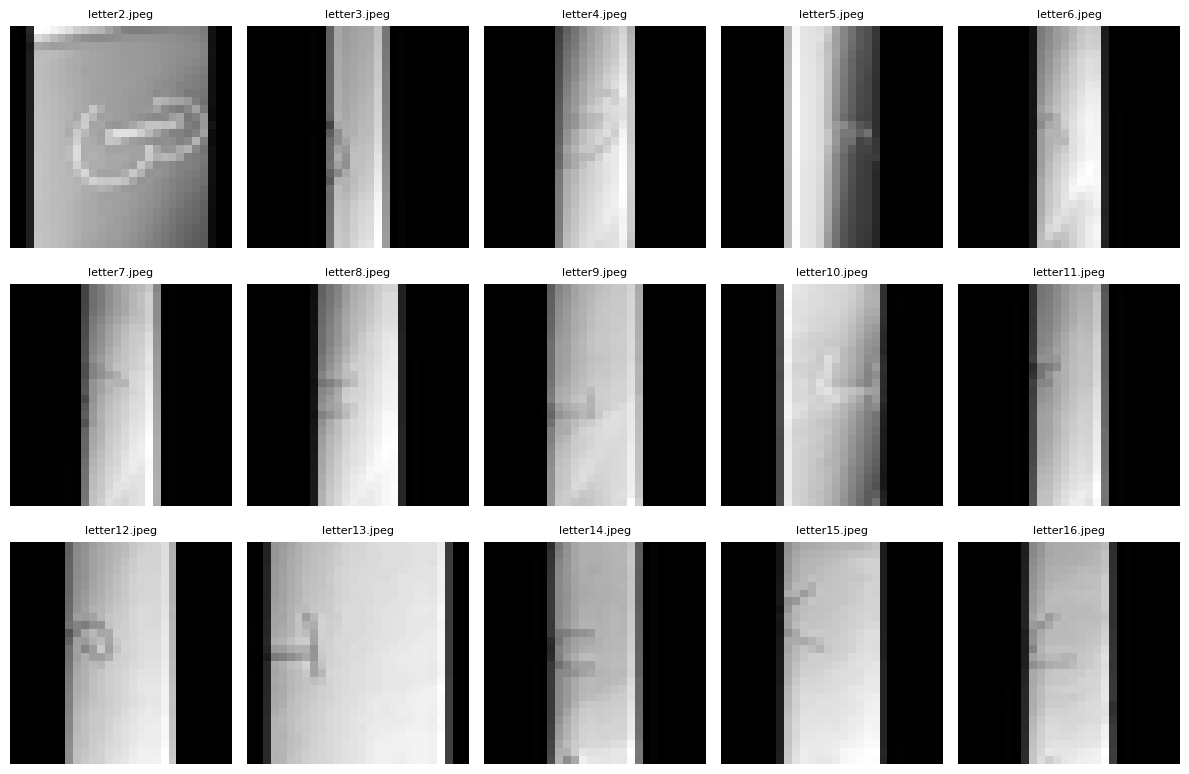

In [24]:
import torch
import numpy as np
from PIL import Image, ImageOps
from torchvision import transforms
import glob, re

def robust_preprocess(image_path, dataset="emnist"):
    img = Image.open(image_path).convert("L")

    # Corner-based background guess (as before)
    w, h = img.size
    corner_px = list(img.crop((0, 0, 10, 10)).getdata()) + \
                list(img.crop((w-10, 0, w, 10)).getdata()) + \
                list(img.crop((0, h-10, 10, h)).getdata()) + \
                list(img.crop((w-10, h-10, w, h)).getdata())
    bg_mean = sum(corner_px) / len(corner_px)
    is_light_bg = bg_mean > 127

    arr = np.array(img).astype(np.float32)

    # Threshold relative to background to find "ink" pixels, regardless of polarity
    if is_light_bg:
        ink_mask = arr < (bg_mean - 30)   # darker-than-background = ink
    else:
        ink_mask = arr > (bg_mean + 30)   # lighter-than-background = ink

    ys, xs = np.where(ink_mask)
    if len(xs) > 0 and len(ys) > 0:
        pad = 15
        x0, x1 = max(xs.min() - pad, 0), min(xs.max() + pad, w)
        y0, y1 = max(ys.min() - pad, 0), min(ys.max() + pad, h)
        img = img.crop((x0, y0, x1, y1))

    if is_light_bg:
        img = ImageOps.invert(img)

    # Pad to square (so resizing to 28x28 doesn't distort aspect ratio)
    w2, h2 = img.size
    size = max(w2, h2)
    square = Image.new("L", (size, size), 0)
    square.paste(img, ((size - w2) // 2, (size - h2) // 2))

    square = square.resize((28, 28), Image.LANCZOS)

    stats = {"mnist": (0.1307, 0.3081), "emnist": (0.1751, 0.3332)}
    mean, std = stats[dataset]
    tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((mean,), (std,))])
    return tf(square).unsqueeze(0)

import matplotlib.pyplot as plt
files = glob.glob("/kaggle/input/datasets/lovego1012/image2/*.jpeg")
files.sort(key=lambda f: int(re.search(r'letter(\d+)', f).group(1)))
files = files[:15]

fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for ax, f in zip(axes.flat, files):
    x = robust_preprocess(f)
    ax.imshow(x.squeeze().numpy(), cmap="gray")
    ax.set_title(f.split("/")[-1], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

Filename             True Label  
-----------------------------------
test_samples/sample1.png L           
test_samples/sample2.png g           
test_samples/sample3.png r           
test_samples/sample4.png g           
test_samples/sample5.png Y           
test_samples/sample6.png V           
test_samples/sample7.png f           
test_samples/sample8.png f           
test_samples/sample9.png W           
test_samples/sample10.png Z           
test_samples/sample11.png A           
test_samples/sample12.png O           
test_samples/sample13.png H           
test_samples/sample14.png V           
test_samples/sample15.png B           


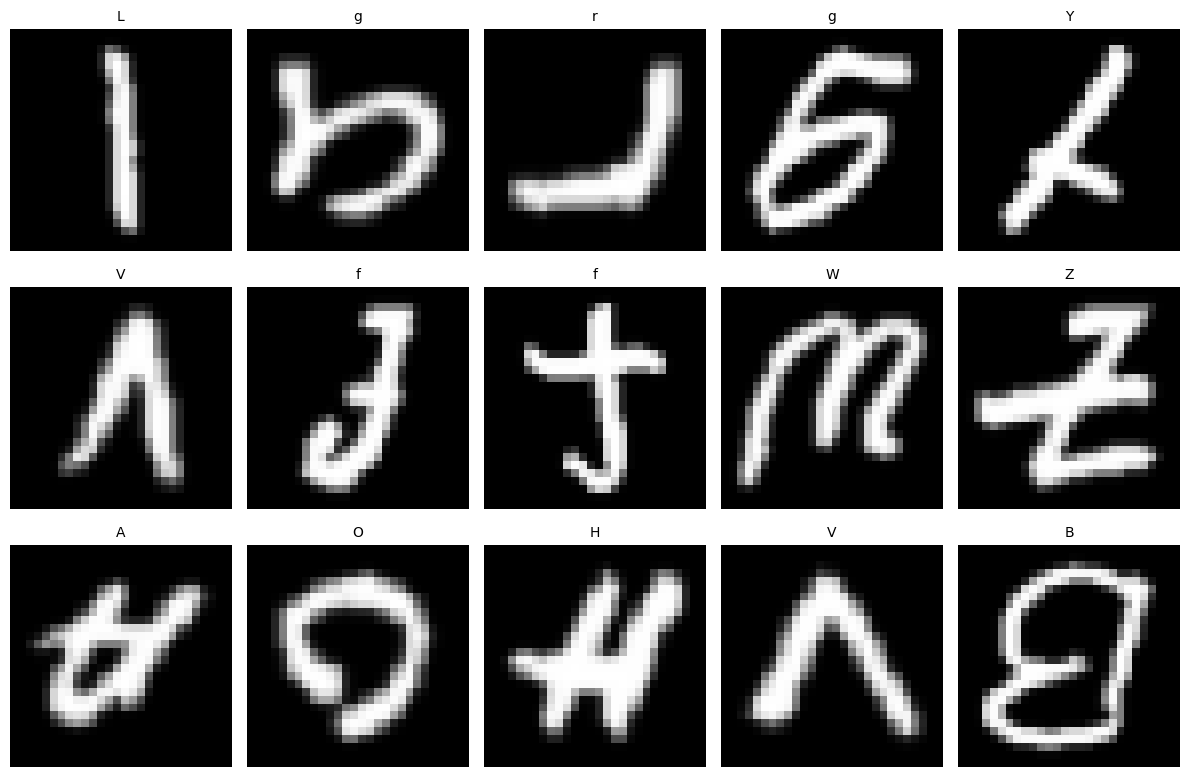

In [25]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from train import fix_emnist_orientation, NUM_CLASSES

EMNIST_BALANCED_LABELS = (
    "0123456789"
    "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    "abdefghnqrt"
)

tf = transforms.Compose([transforms.Lambda(fix_emnist_orientation)])
test_ds = datasets.EMNIST("./data", split="balanced", train=False, download=True, transform=tf)

os.makedirs("test_samples", exist_ok=True)

# Grab 15 random test images, save as PNGs, and remember their true labels
import random
random.seed(0)
indices = random.sample(range(len(test_ds)), 15)

print(f"{'Filename':<20} {'True Label':<12}")
print("-" * 35)
for i, idx in enumerate(indices):
    img, label = test_ds[idx]
    fname = f"test_samples/sample{i+1}.png"
    img.save(fname)
    print(f"{fname:<20} {EMNIST_BALANCED_LABELS[label]:<12}")

# Show them so you can see what "correct" EMNIST-format input looks like
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for ax, idx in zip(axes.flat, indices):
    img, label = test_ds[idx]
    ax.imshow(img, cmap="gray")
    ax.set_title(EMNIST_BALANCED_LABELS[label], fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [26]:
import glob
from infer import load_and_preprocess
from model import CharCNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load("checkpoints/balanced_best.pt", map_location=device)
model = CharCNN(num_classes=ckpt["num_classes"]).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

files = sorted(glob.glob("test_samples/*.png"), key=lambda f: int(f.split("sample")[1].split(".")[0]))
for f in files:
    x = load_and_preprocess(f).to(device)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        conf, pred_idx = probs.max(dim=1)
    label = EMNIST_BALANCED_LABELS[pred_idx.item()]
    print(f"{f}: predicted '{label}' ({conf.item():.2%})")

ValueError: invalid literal for int() with base 10: 's/'

In [27]:
import re
files = sorted(glob.glob("test_samples/*.png"), key=lambda f: int(re.search(r'sample(\d+)\.png', f).group(1)))
for f in files:
    x = load_and_preprocess(f).to(device)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        conf, pred_idx = probs.max(dim=1)
    label = EMNIST_BALANCED_LABELS[pred_idx.item()]
    print(f"{f}: predicted '{label}' ({conf.item():.2%})")
    

test_samples/sample1.png: predicted 'I' (35.09%)
test_samples/sample2.png: predicted 'a' (60.65%)
test_samples/sample3.png: predicted 'r' (97.93%)
test_samples/sample4.png: predicted 'g' (97.73%)
test_samples/sample5.png: predicted 'Y' (95.29%)
test_samples/sample6.png: predicted 'V' (99.86%)
test_samples/sample7.png: predicted 'F' (34.12%)
test_samples/sample8.png: predicted 'f' (59.17%)
test_samples/sample9.png: predicted 'W' (99.94%)
test_samples/sample10.png: predicted 'Z' (99.58%)
test_samples/sample11.png: predicted 'A' (99.96%)
test_samples/sample12.png: predicted 'O' (55.55%)
test_samples/sample13.png: predicted 'H' (99.57%)
test_samples/sample14.png: predicted 'V' (99.98%)
test_samples/sample15.png: predicted 'B' (99.98%)


In [28]:
!ls checkpoints/

balanced_best.pt  mnist_best.pt


In [29]:
!ls -lh checkpoints/

total 6.8M
-rw-r--r-- 1 root root 3.4M Sep  6 00:09 balanced_best.pt
-rw-r--r-- 1 root root 3.4M Sep  6 00:02 mnist_best.pt


In [30]:
!ls -lh checkpoints/mnist_best.pt

-rw-r--r-- 1 root root 3.4M Sep  6 00:02 checkpoints/mnist_best.pt


In [31]:
from IPython.display import FileLink
FileLink('checkpoints/mnist_best.pt')


/kaggle/working/checkpoints/mnist_best.pt

In [32]:
FileLink('checkpoints/balanced_best.pt')

/kaggle/working/checkpoints/balanced_best.pt